# EDA tabel metadata putusan

Notebook ini membaca `data/metadata.csv` (hasil `python -m src.metadata`) dan menjawab pertanyaan dasar tentang dataset sebelum membangun RAG.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/metadata.csv')
print(df.shape)
df.head()

(51, 22)


,nomor,no_urut,file,halaman,n_kata,n_terdakwa,terdakwa,umur,pekerjaan,penasihat_hukum,...,berat_netto_gram,tuntutan_bulan,vonis_bulan,denda_rp,subsider_bulan,bebas_dakwaan_primair,rehabilitasi,hakim_ketua,tgl_musyawarah,tgl_diucapkan
0,105/Pid.Sus/2023/PN Rap,105,no_watermark_zaee29d9df4b2364bb8c313132333432.pdf,23,6712,1,FAHMI AZHARI SITUMORANG Alias FAHMI,24,Wiraswasta,True,...,1.04,96,48,1.000000e+09,3.0,True,False,Hendrik Tarigan,12 Juli 2023,12 Juli 2023
1,159/Pid.Sus/2023/PN Rap,159,no_watermark_zaee30e135a87ae6abce313030333532.pdf,28,8224,1,MUHAMMAD KHAIRUL ALIAS BARUL,32,Satpam,True,...,0.53,72,66,1.000000e+09,3.0,True,False,Hendrik Tarigan,18 Juli 2023,26 Juli 2023
2,188/Pid.Sus/2023/PN Rap,188,no_watermark_zaee21ec04d724c088df303931333237.pdf,26,8088,1,ASRIL FAUZI NASUTION ALIAS DEDEK,32,Buruh,True,...,0.47,82,60,1.000000e+09,3.0,False,False,Hendrik Tarigan,6 Juni 2023,20 Juni 2023
3,222/Pid.Sus/2023/PN Rap,222,no_watermark_zaee29d9dd8390848cea313132333339.pdf,28,8487,1,DAUD BATUBARA Alias DAUD,29,Mocok-mocok,True,...,0.58,84,60,1.000000e+09,6.0,True,False,Hendrik Tarigan,12 Juli 2023,12 Juli 2023
4,235/Pid.Sus/2023/PN Rap,235,no_watermark_zaee2a048ba4b6008d41313632393130.pdf,33,10274,1,REDO TAMBUNAN ALIAS REDO,37,Tidak Bekerja,True,...,24.06,120,80,1.000000e+09,3.0,False,False,Hendrik Tarigan,12 Juli 2023,18 Juli 2023


In [3]:
df.isna().sum()[lambda s: s > 0]

berat_netto_gram    2
denda_rp            3
subsider_bulan      3
dtype: int64

## Code 4 - Distribusi Vonis

count     51.000000
mean      66.196078
std       21.007636
min       12.000000
25%       60.000000
50%       66.000000
75%       78.000000
max      144.000000
Name: vonis_bulan, dtype: float64


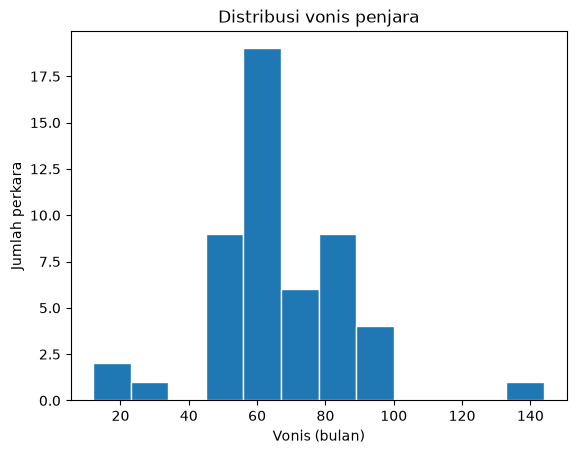

In [4]:
print(df['vonis_bulan'].describe())
ax = df['vonis_bulan'].plot.hist(bins=12, edgecolor='white')
ax.set_xlabel('Vonis (bulan)'); ax.set_ylabel('Jumlah perkara'); ax.set_title('Distribusi vonis penjara')
plt.show()

## Code 5 - Vonis Per Pasal

In [8]:
df['pasal_utama'] = df['pasal'].str.split(',').str[0]
ringkas = df.groupby('pasal_utama')['vonis_bulan'].agg(['count', 'median', 'min', 'max']).sort_values('count', ascending=False)
ringkas

,count,median,min,max
pasal_utama,,,,
112(1),25,60.0,24,84
114(1),16,75.0,60,96
114(2),4,90.0,72,144
112(2),3,60.0,60,80
127(1)a,3,18.0,12,46


## Code 6 - Tuntutan VS Vonis

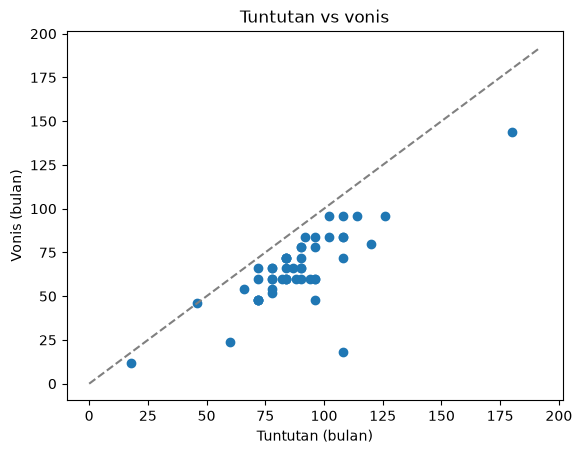

Median vonis/tuntutan: 77%
Vonis < tuntutan: 50 dari 51 perkara


In [5]:
fig, ax = plt.subplots()
ax.scatter(df['tuntutan_bulan'], df['vonis_bulan'])
batas = [0, df[['tuntutan_bulan', 'vonis_bulan']].max().max() + 12]
ax.plot(batas, batas, linestyle='--', color='gray')
ax.set_xlabel('Tuntutan (bulan)'); ax.set_ylabel('Vonis (bulan)'); ax.set_title('Tuntutan vs vonis')
plt.show()
rasio = df['vonis_bulan'] / df['tuntutan_bulan']
print(f"Median vonis/tuntutan: {rasio.median():.0%}")
print(f"Vonis < tuntutan: {(df['vonis_bulan'] < df['tuntutan_bulan']).sum()} dari {len(df)} perkara")

Hasil dari tuntutan vs vonis adalah semua perkara berada di bawah garis diagonal berarti vonis lebih ringan dari tuntutan.

## Code 7 - Hakim Ketua, Penasihat Hukum, Dakwaan Primair

In [6]:
print(df['hakim_ketua'].value_counts(), '\n')
print('Didampingi penasihat hukum:', int(df['penasihat_hukum'].sum()))
print('Bebas dari dakwaan primair (tetap dihukum):', int(df['bebas_dakwaan_primair'].sum()))
print('Putusan dengan >1 terdakwa:', int((df['n_terdakwa'] > 1).sum()))

hakim_ketua
Hendrik Tarigan         19
Tommy Manik             14
Welly Irdianto          12
Muhammad Alqudri         5
Vini Dian Afrilia P.     1
Name: count, dtype: int64 

Didampingi penasihat hukum: 49
Bebas dari dakwaan primair (tetap dihukum): 19
Putusan dengan >1 terdakwa: 6


## Code 8 - Tanggal Musyawarah VS Diucapkan

In [7]:
beda = df[df['tgl_musyawarah'] != df['tgl_diucapkan']]
print(f'{len(beda)} dari {len(df)} perkara diucapkan pada hari yang berbeda dari musyawarah')
beda[['nomor', 'tgl_musyawarah', 'tgl_diucapkan']].head()

44 dari 51 perkara diucapkan pada hari yang berbeda dari musyawarah


,nomor,tgl_musyawarah,tgl_diucapkan
1,159/Pid.Sus/2023/PN Rap,18 Juli 2023,26 Juli 2023
2,188/Pid.Sus/2023/PN Rap,6 Juni 2023,20 Juni 2023
4,235/Pid.Sus/2023/PN Rap,12 Juli 2023,18 Juli 2023
6,269/Pid.Sus/2023/PN Rap,15 Agustus 2023,29 Agustus 2023
7,307/Pid.Sus/2023/PN Rap,25 Juli 2023,27 Juli 2023
